In [1]:
# ==========================================
# STEP 1: Import Required Libraries
# ==========================================

# Numerical computations
import numpy as np

# Data manipulation
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")

In [2]:
# ==========================================
# STEP 2: Upload and Load Dataset
# ==========================================

from google.colab import files

# Upload the wine.csv dataset
uploaded = files.upload()

# Read the dataset
df = pd.read_csv("wine.csv")

# Display first five rows
print(df.head())

# Display dataset shape
print("\nDataset Shape:", df.shape)

Saving wine.csv to wine.csv
   Type  Alcohol  Malic   Ash  Alcalinity  Magnesium  Phenols  Flavanoids  \
0     1    14.23   1.71  2.43        15.6        127     2.80        3.06   
1     1    13.20   1.78  2.14        11.2        100     2.65        2.76   
2     1    13.16   2.36  2.67        18.6        101     2.80        3.24   
3     1    14.37   1.95  2.50        16.8        113     3.85        3.49   
4     1    13.24   2.59  2.87        21.0        118     2.80        2.69   

   Nonflavanoids  Proanthocyanins  Color   Hue  Dilution  Proline  
0           0.28             2.29   5.64  1.04      3.92     1065  
1           0.26             1.28   4.38  1.05      3.40     1050  
2           0.30             2.81   5.68  1.03      3.17     1185  
3           0.24             2.18   7.80  0.86      3.45     1480  
4           0.39             1.82   4.32  1.04      2.93      735  

Dataset Shape: (178, 14)


In [3]:
# ==========================================
# STEP 3: Basic Data Exploration
# ==========================================

# Display basic information about dataset
print(df.info())

# Display statistical summary
print(df.describe())

# Check missing values
print("\nMissing Values")
print(df.isnull().sum())

# Check duplicate records
print("\nDuplicate Rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB
None
             Type     Alcohol       Malic         Ash  Alcalinity   Magnesium  \
count  178.000000  17

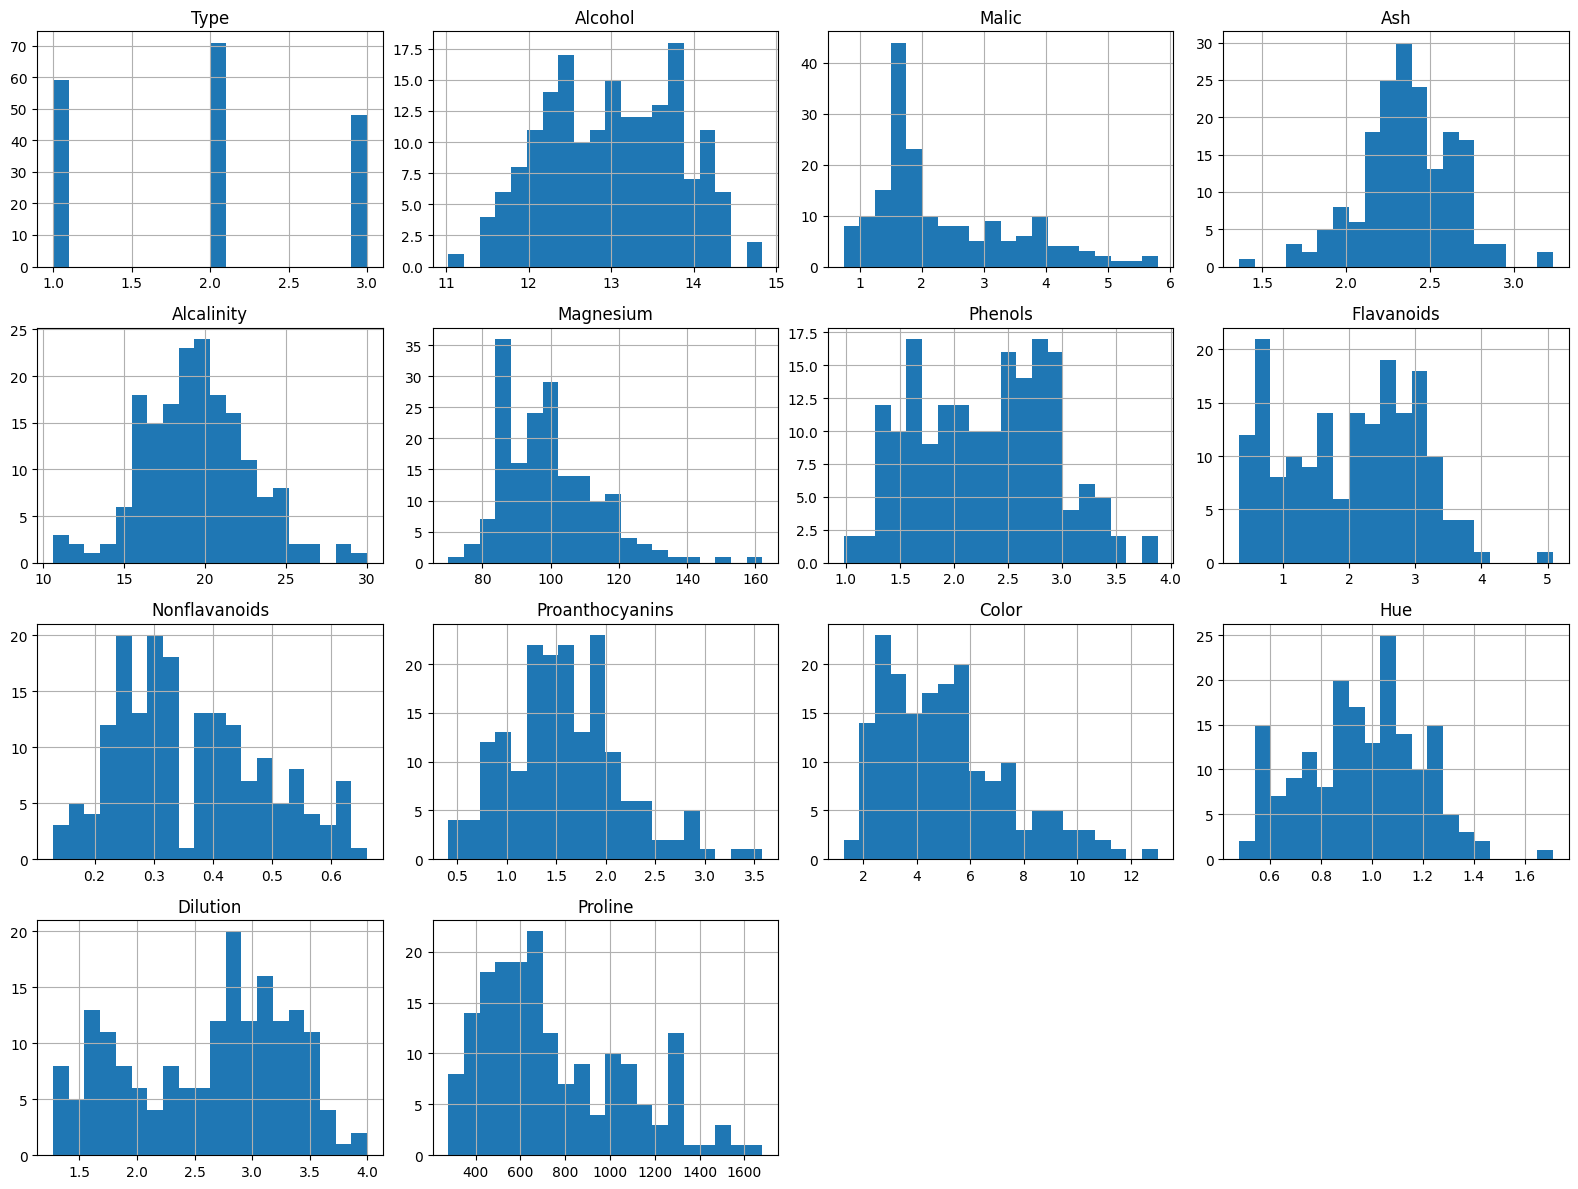

In [4]:
# ==========================================
# STEP 4: Histogram of Features
# ==========================================

# Plot histograms for all numerical columns
df.hist(figsize=(16,12), bins=20)

# Adjust layout
plt.tight_layout()

# Display plots
plt.show()

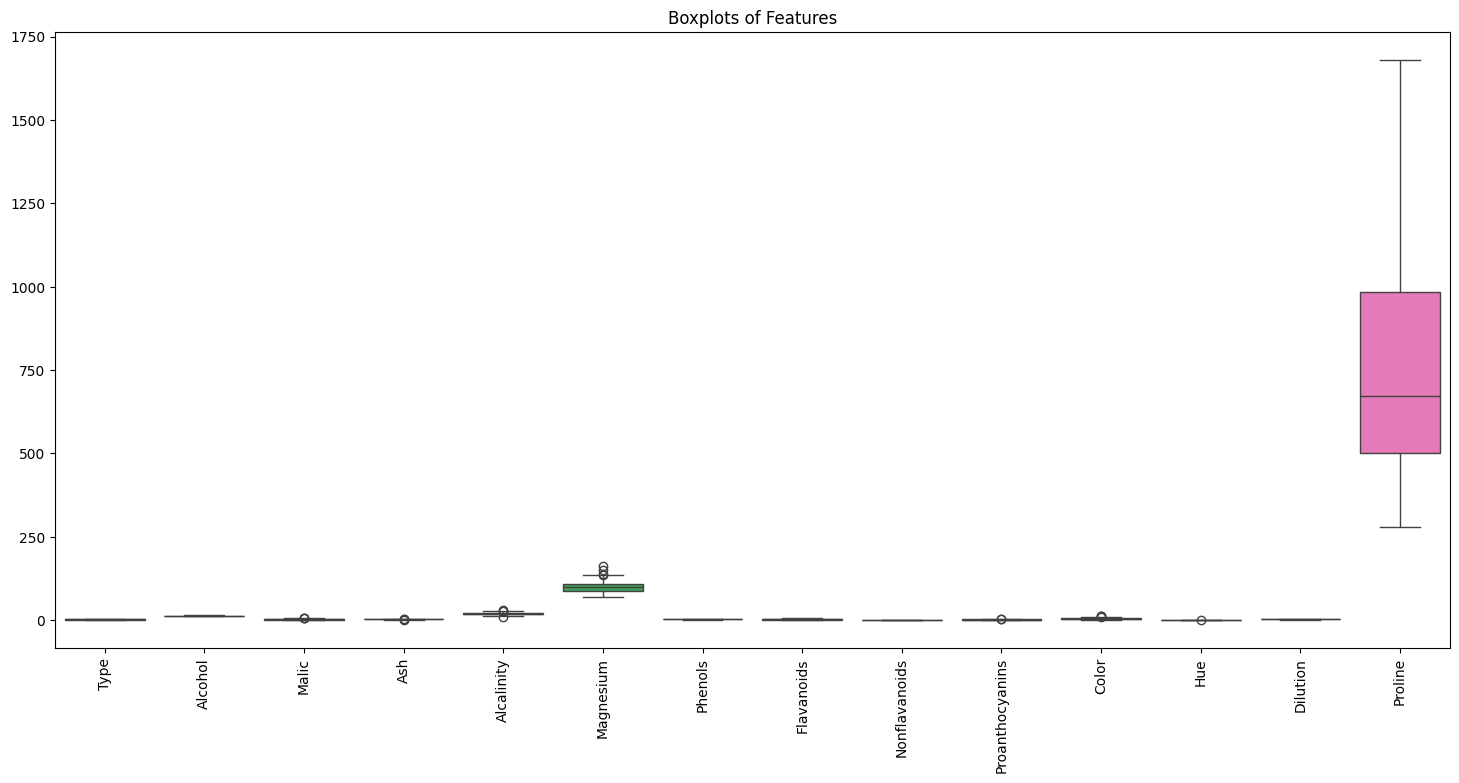

In [5]:
# ==========================================
# STEP 5: Boxplots for Outlier Detection
# ==========================================

# Create boxplots for every feature
plt.figure(figsize=(18,8))

sns.boxplot(data=df)

# Rotate x-axis labels
plt.xticks(rotation=90)

plt.title("Boxplots of Features")

plt.show()

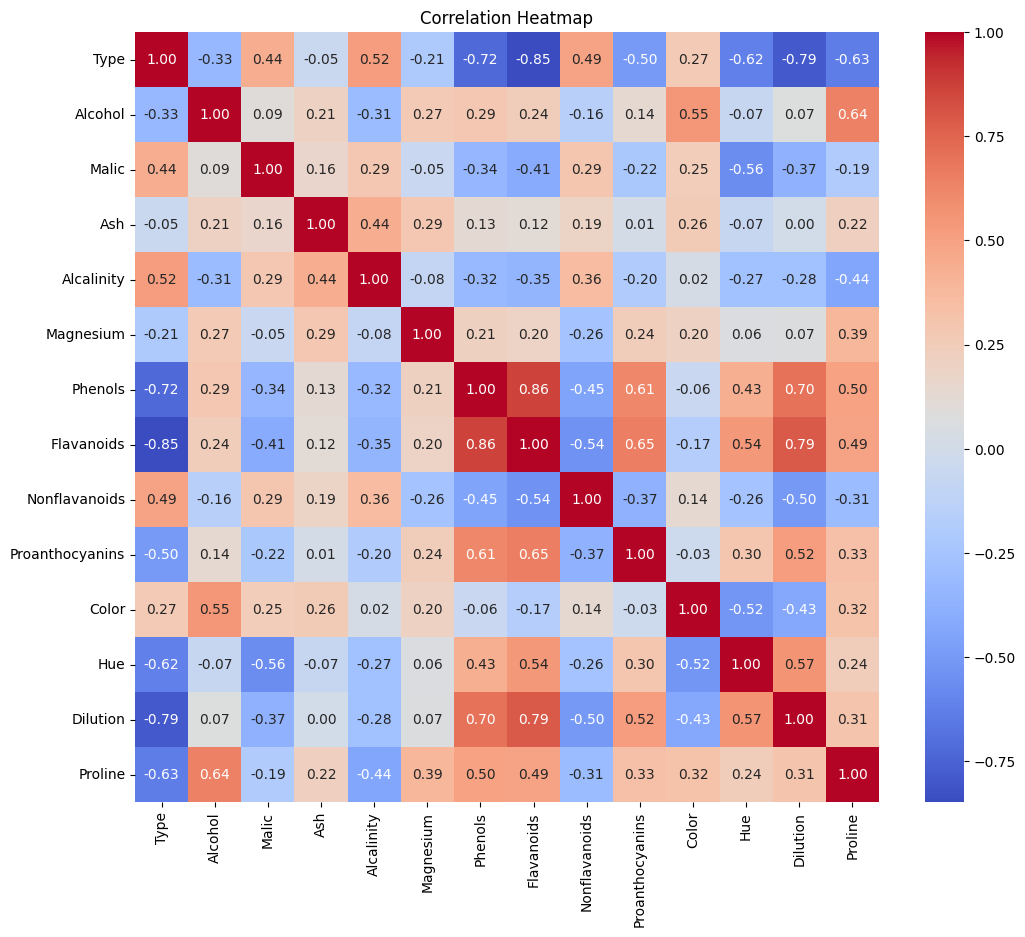

In [6]:
# ==========================================
# STEP 6: Correlation Heatmap
# ==========================================

# Calculate correlation matrix
corr = df.corr()

# Plot heatmap
plt.figure(figsize=(12,10))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

In [7]:
# ==========================================
# STEP 7: Standardize the Features
# ==========================================

# Separate target column if present
# Wine dataset stores class in first column

X = df.iloc[:,1:]

# Standardize the data
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Shape after scaling:", X_scaled.shape)

Shape after scaling: (178, 13)


In [8]:
# ==========================================
# STEP 8: Apply Principal Component Analysis
# ==========================================

# Create PCA model
pca = PCA()

# Fit PCA on standardized data
X_pca = pca.fit_transform(X_scaled)

print("Shape after PCA:", X_pca.shape)

Shape after PCA: (178, 13)


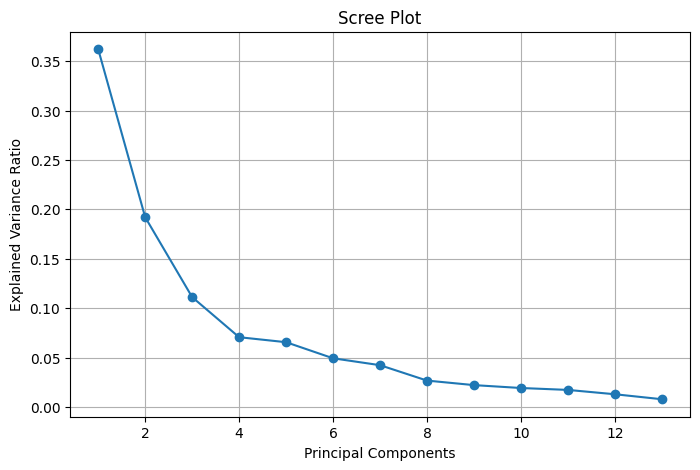

In [9]:
# ==========================================
# STEP 9: Scree Plot
# ==========================================

# Plot explained variance ratio
plt.figure(figsize=(8,5))

plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_,
         marker='o')

plt.xlabel("Principal Components")

plt.ylabel("Explained Variance Ratio")

plt.title("Scree Plot")

plt.grid(True)

plt.show()

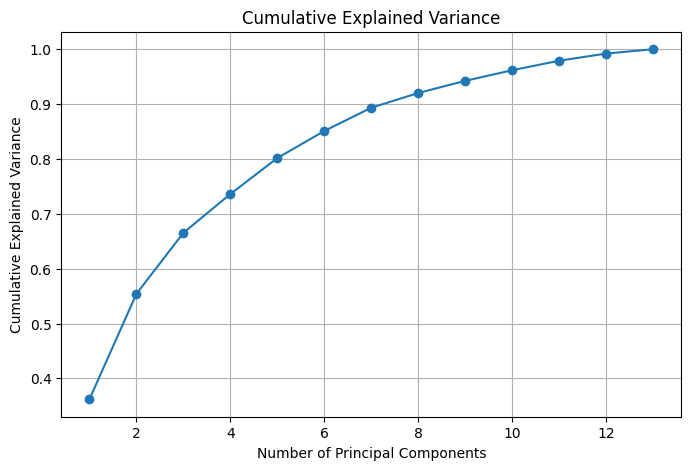

[0.36198848 0.55406338 0.66529969 0.73598999 0.80162293 0.85098116
 0.89336795 0.92017544 0.94239698 0.96169717 0.97906553 0.99204785
 1.        ]


In [10]:
# ==========================================
# STEP 10: Cumulative Explained Variance
# ==========================================

# Calculate cumulative variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))

plt.plot(range(1, len(cumulative_variance)+1),
         cumulative_variance,
         marker='o')

plt.xlabel("Number of Principal Components")

plt.ylabel("Cumulative Explained Variance")

plt.title("Cumulative Explained Variance")

plt.grid(True)

plt.show()

print(cumulative_variance)

In [11]:
# ==========================================
# STEP 11: Reduce Dataset using PCA
# ==========================================

# Retain enough components to explain 95% variance
pca_final = PCA(n_components=0.95)

X_pca_final = pca_final.fit_transform(X_scaled)

print("Original Shape :", X_scaled.shape)

print("Reduced Shape :", X_pca_final.shape)

Original Shape : (178, 13)
Reduced Shape : (178, 10)


In [12]:
# ==========================================
# STEP 12: K-Means Clustering on Original Data
# ==========================================

# Create KMeans model
kmeans_original = KMeans(n_clusters=3,
                         random_state=42)

# Fit model
original_clusters = kmeans_original.fit_predict(X_scaled)

# Calculate evaluation metrics
silhouette_original = silhouette_score(X_scaled,
                                       original_clusters)

db_original = davies_bouldin_score(X_scaled,
                                   original_clusters)

print("Silhouette Score :", silhouette_original)

print("Davies-Bouldin Index :", db_original)

Silhouette Score : 0.2848589191898987
Davies-Bouldin Index : 1.3891879777181648


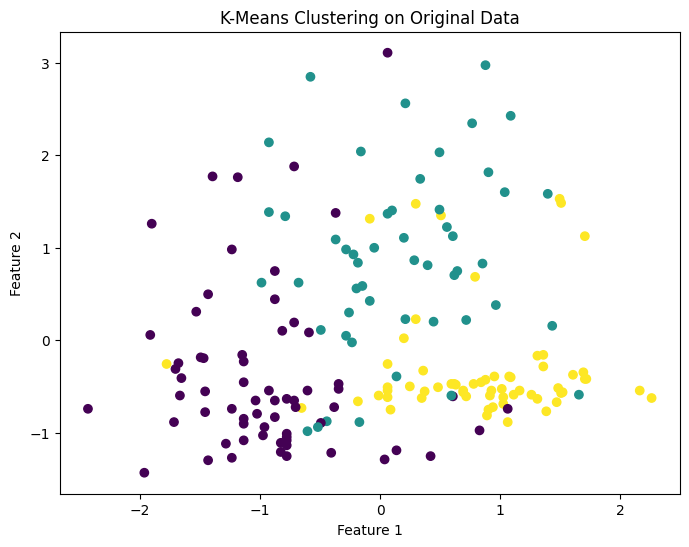

In [13]:
# ==========================================
# STEP 13: Visualize Original Clusters
# ==========================================

# Scatter plot using first two features
plt.figure(figsize=(8,6))

plt.scatter(X_scaled[:,0],
            X_scaled[:,1],
            c=original_clusters,
            cmap='viridis')

plt.xlabel("Feature 1")

plt.ylabel("Feature 2")

plt.title("K-Means Clustering on Original Data")

plt.show()

In [14]:
# ==========================================
# STEP 14: K-Means Clustering on PCA Data
# ==========================================

# Apply KMeans to PCA-transformed dataset
kmeans_pca = KMeans(n_clusters=3,
                    random_state=42)

pca_clusters = kmeans_pca.fit_predict(X_pca_final)

# Evaluation metrics
silhouette_pca = silhouette_score(X_pca_final,
                                  pca_clusters)

db_pca = davies_bouldin_score(X_pca_final,
                              pca_clusters)

print("Silhouette Score :", silhouette_pca)

print("Davies-Bouldin Index :", db_pca)

Silhouette Score : 0.29867482943692886
Davies-Bouldin Index : 1.3363263335155773


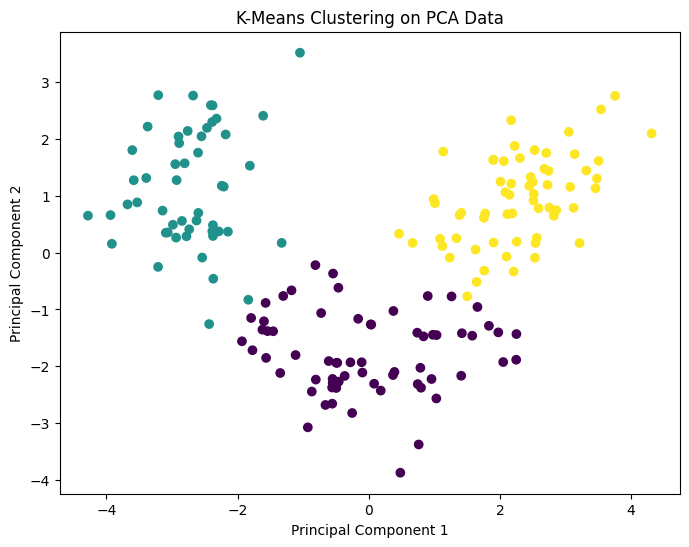

In [15]:
# ==========================================
# STEP 15: Visualize PCA Clusters
# ==========================================

# Scatter plot using first two principal components
plt.figure(figsize=(8,6))

plt.scatter(X_pca_final[:,0],
            X_pca_final[:,1],
            c=pca_clusters,
            cmap='viridis')

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("K-Means Clustering on PCA Data")

plt.show()

In [16]:
# ==========================================
# STEP 16: Compare Clustering Performance
# ==========================================

comparison = pd.DataFrame({

    "Dataset":[
        "Original Data",
        "PCA Data"
    ],

    "Silhouette Score":[
        silhouette_original,
        silhouette_pca
    ],

    "Davies-Bouldin Index":[
        db_original,
        db_pca
    ]

})

print(comparison)

         Dataset  Silhouette Score  Davies-Bouldin Index
0  Original Data          0.284859              1.389188
1       PCA Data          0.298675              1.336326


In [17]:
# ==========================================
# STEP 17: Final Conclusion
# ==========================================

print("Conclusion")
print("----------------------------------")
print("1. PCA reduced the dimensionality of the dataset.")
print("2. Clustering was performed on both original and PCA-transformed data.")
print("3. Silhouette Score indicates better cluster separation when higher.")
print("4. Davies-Bouldin Index indicates better clustering when lower.")
print("5. Compare both metrics to determine whether PCA improved clustering performance.")

Conclusion
----------------------------------
1. PCA reduced the dimensionality of the dataset.
2. Clustering was performed on both original and PCA-transformed data.
3. Silhouette Score indicates better cluster separation when higher.
4. Davies-Bouldin Index indicates better clustering when lower.
5. Compare both metrics to determine whether PCA improved clustering performance.
